1) Install Required Libraries

In [68]:
pip install geopandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2) Read a Shapefile in Python

In [69]:
import os
from pathlib import Path
import geopandas as gpd
import pandas as pd

# Build path to the shapefile and handle a common double-extension mistake
shp_path = Path(r"C:\Users\oluwa\OneDrive\Desktop\Personal Geospatial Science Content\state\State.shp")
if not shp_path.exists():
    # try the common mistaken double extension (State.shp.shp)
    alt = Path(str(shp_path) + '.shp')
    if alt.exists():
        shp_path = alt
    else:
        raise FileNotFoundError(f"Shapefile not found: {shp_path} or {alt}")

# Read shapefile
gdf = gpd.read_file(str(shp_path))

# View first rows
print(gdf.head())

# Check CRS (coordinate system)
print(gdf.crs)

   ogc_fid   rowid  ogc_fid0 geozone                              globalid  \
0      1.0  1153.0    1153.0     SWZ  41307165-bb56-431a-9cab-026e3bee2480   
1      2.0  1156.0    1156.0     SWZ  05fc3e53-ce0a-491d-9b37-2e9f1e3651fb   
2      3.0  1161.0    1161.0     NCZ  17379e56-2427-44bc-9778-9836eac9fcc4   
3      4.0  1162.0    1162.0     SSZ  8fda629d-9983-43d2-b5dc-559e03942bbd   
4      5.0  1167.0    1167.0     NCZ  fef85acc-cc49-42cb-86ef-c24e93a1d746   

                   timestamp     source     capcity statename statecode  \
0  2018-12-13T09:31:33+01:00  eHA_Polio         Ado     Ekiti        EK   
1  2018-12-13T09:31:33+01:00  eHA_Polio     Oshogbo      Osun        OS   
2  2018-12-13T09:31:33+01:00  eHA_Polio         Jos   Plateau        PL   
3  2018-12-13T09:31:33+01:00  eHA_Polio  Benin City       Edo        ED   
4  2018-12-13T09:31:33+01:00  eHA_Polio       Lafia  Nasarawa        NA   

            editor  ratio print orie  \
0  abraham.oluseye  1.120  Landscape   


3) Join Population Table to State Shapefile

In [70]:
# ----------------------------------
# 1. File paths
# ----------------------------------
population_table = r"C:\Users\oluwa\OneDrive\Desktop\Personal Geospatial Science Content\Population_state.csv"

# Check columns
print("Shapefile columns:")
print(gdf.columns)

# ----------------------------------
# 3. Read population table
# ----------------------------------
pop = pd.read_csv(population_table)

print("Population table columns:")
print(pop.columns)

# ----------------------------------
# 4. Clean state names (important for matching)
# ----------------------------------
# Ensure we have a consistent state name column in the shapefile
if 'statename' not in gdf.columns:
    for candidate in ['NAME', 'name', 'STATE_NAME', 'State']:
        if candidate in gdf.columns:
            gdf['statename'] = gdf[candidate].astype(str)
            break
    else:
        raise KeyError('No suitable state name column found in shapefile; expected one of statename/NAME/name/STATE_NAME/State')

gdf['statename'] = gdf['statename'].str.strip().str.lower()

# Clean population table state column (allow some common alternatives)
if 'State' not in pop.columns:
    alt_state = next((c for c in pop.columns if c.strip().lower() in ['state','state_name','st','state code','statecode']), None)
    if alt_state is not None:
        pop = pop.rename(columns={alt_state: 'State'})
    else:
        raise KeyError("Population table must contain a 'State' column")
pop['State'] = pop['State'].astype(str).str.strip().str.lower()

# Find population column (prefer numeric columns with population-like names)
pop_col = None
candidates = ['total','population','pop','people','count']
# Count numeric-convertible values per column
numeric_counts = {c: pd.to_numeric(pop[c], errors='coerce').notna().sum() for c in pop.columns}
# 1) pick name-matching columns that are numeric and choose the one with most numeric values
name_matches = [c for c in pop.columns if any(k in c.strip().lower() for k in candidates) or 'total' in c.strip().lower() or 'population' in c.strip().lower()]
num_name_matches = [c for c in name_matches if numeric_counts.get(c, 0) > 0]
if num_name_matches:
    pop_col = max(num_name_matches, key=lambda c: numeric_counts[c])
# 2) fallback: pick any column with the most numeric values
elif max(numeric_counts.values()) > 0:
    pop_col = max(numeric_counts, key=numeric_counts.get)
# 3) last resort: sum Male + Female if present
else:
    cols_lc = [c.strip().lower() for c in pop.columns]
    if 'male' in cols_lc and 'female' in cols_lc:
        try:
            male_col = next(c for c in pop.columns if c.strip().lower() == 'male')
            female_col = next(c for c in pop.columns if c.strip().lower() == 'female')
            pop['Total'] = pd.to_numeric(pop[male_col], errors='coerce') + pd.to_numeric(pop[female_col], errors='coerce')
            pop_col = 'Total'
        except Exception:
            pop_col = None
    else:
        pop_col = None

if pop_col is None:
    raise KeyError("No population column found in population table. Expected a numeric Total/Population column or numeric Male+Female columns to sum.")

print(f"Using population column: {pop_col}")
# Ensure the chosen population column is numeric in the source table before merging
pop[pop_col] = pd.to_numeric(pop[pop_col], errors='coerce')
print(f"After coercion, numeric values in population column: {pop[pop_col].notna().sum()} / {len(pop)}")
# ----------------------------------
# 5. Perform table join
# ----------------------------------
states_joined = gdf.merge(
    pop[['State', pop_col]],   # only bring needed columns
    left_on='statename',
    right_on='State',
    how='left'
)

# ----------------------------------
# 6. Rename population column
# ----------------------------------
states_joined = states_joined.rename(columns={pop_col:'Total_Population'})

print(states_joined.head())
# Diagnostic: show detected population column and sample values
print("Detected population column:", pop_col)
print("Sample values in population table (head):")
print(pop[[pop_col]].head())
print("Dtype in population table:", pop[pop_col].dtype)
print("Numeric-converted count in population table:", pd.to_numeric(pop[pop_col], errors='coerce').notna().sum(), "/", len(pop))
print("Sample of numeric-converted values:")
print(pd.to_numeric(pop[pop_col], errors='coerce').head())
print()
print("States joined Total_Population column preview:")
print(states_joined[['statename', 'State', 'Total_Population']].head())
print("Total_Population dtype:", states_joined['Total_Population'].dtype)
if states_joined['Total_Population'].dtype == object:
    conv = pd.to_numeric(states_joined['Total_Population'], errors='coerce')
    print("Numeric-convertible count in states_joined['Total_Population']:", conv.notna().sum(), "/", len(states_joined))
    print("Example converted values:")
    print(conv.head())

Shapefile columns:
Index(['ogc_fid', 'rowid', 'ogc_fid0', 'geozone', 'globalid', 'timestamp',
       'source', 'capcity', 'statename', 'statecode', 'editor', 'ratio',
       'print orie', 'geometry'],
      dtype='str')
Population table columns:
Index(['State code', 'State', 'Notes', 'Population Data Source', 'Female',
       'Male', 'Total'],
      dtype='str')
Using population column: Total
After coercion, numeric values in population column: 37 / 37
   ogc_fid   rowid  ogc_fid0 geozone                              globalid  \
0      1.0  1153.0    1153.0     SWZ  41307165-bb56-431a-9cab-026e3bee2480   
1      2.0  1156.0    1156.0     SWZ  05fc3e53-ce0a-491d-9b37-2e9f1e3651fb   
2      3.0  1161.0    1161.0     NCZ  17379e56-2427-44bc-9778-9836eac9fcc4   
3      4.0  1162.0    1162.0     SSZ  8fda629d-9983-43d2-b5dc-559e03942bbd   
4      5.0  1167.0    1167.0     NCZ  fef85acc-cc49-42cb-86ef-c24e93a1d746   

                   timestamp     source     capcity statename statecode  \

4) Basic Plot of the Shapefile

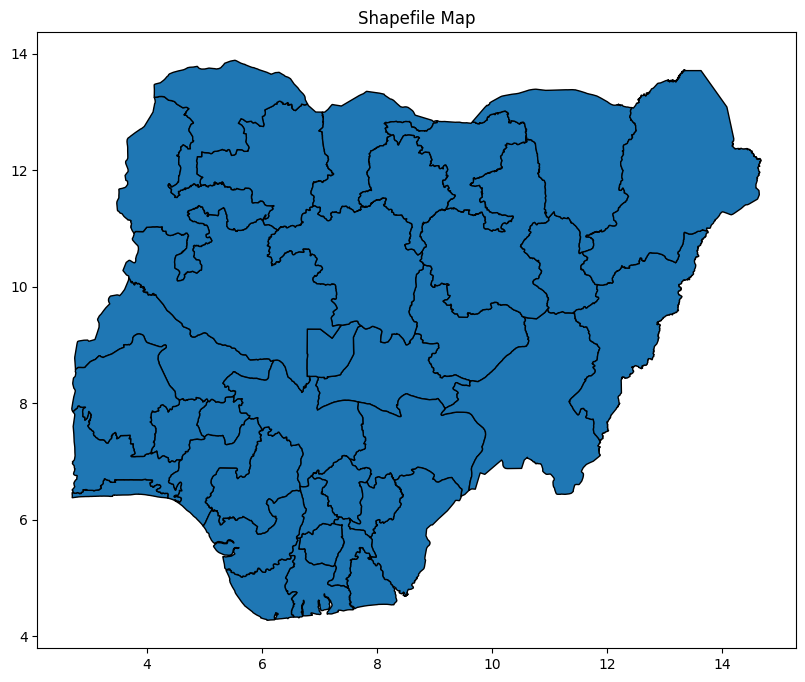

In [71]:
import matplotlib.pyplot as plt

states_joined.plot(figsize=(10, 8), edgecolor="black")
plt.title("Shapefile Map")
plt.show()

4) Plot with Color Based on an Attribute Column

Example: The shapefile has a column called "Total_Population".

5) Change Map Style (Better Visualization)

In [72]:
!pip install contextily


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Step 1 — Verify the Data (Very Important)

In [73]:
print(states_joined[plot_col].head())
print(states_joined[plot_col].describe())
print(states_joined[plot_col].isna().sum())

0    1670218.030
1    4624443.559
2    7156275.528
3    3911586.970
4    4827215.303
Name: Total_Population, dtype: float64
count    3.700000e+01
mean     5.954633e+06
std      3.187870e+06
min      1.079701e+06
25%      3.984817e+06
50%      5.200929e+06
75%      7.156276e+06
max      1.794073e+07
Name: Total_Population, dtype: float64
0


Step 2 — Clean and Validate the Data Before Plotting

Add this data validation block before plotting.

In [74]:
# Convert population column safely
states_joined[plot_col] = (
    states_joined[plot_col]
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

states_joined[plot_col] = pd.to_numeric(states_joined[plot_col], errors='coerce')

# Remove rows with missing population
states_map = states_joined.dropna(subset=[plot_col])

# Check if data still exists
if states_map.empty:
    raise ValueError("Population column contains no valid numeric values after cleaning.")

Step 3 —Choropleth Plot Section


Map saved successfully as population_state_map.png


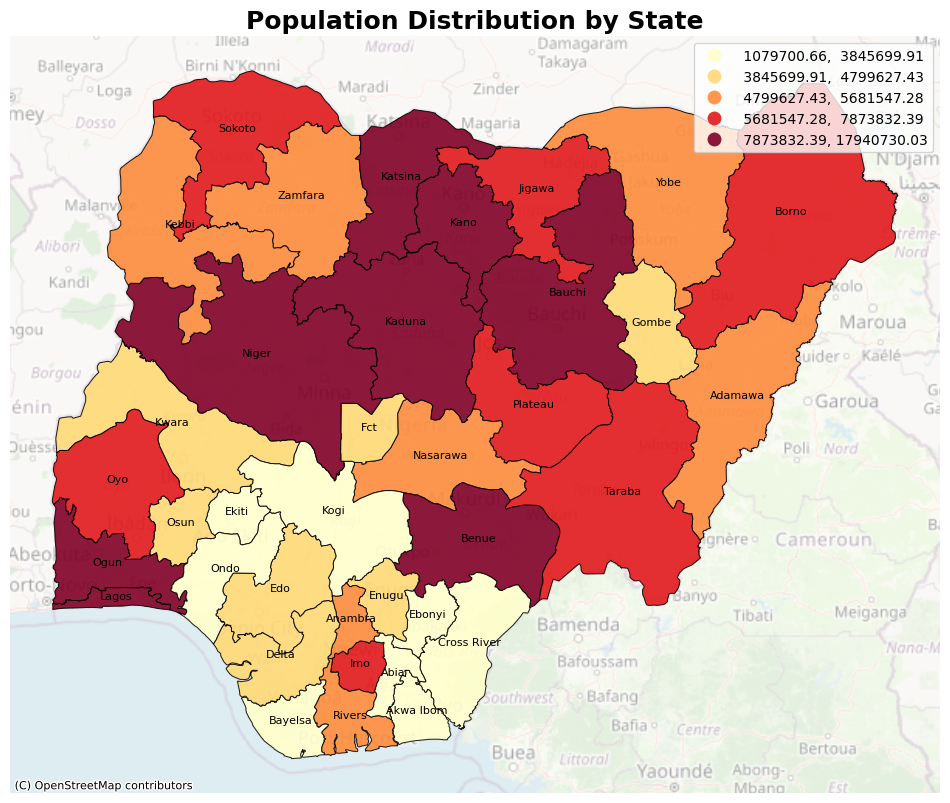

In [75]:
# Reproject for basemap
states_map = states_map.to_crs(epsg=3857)

# Create centroids for labeling
states_map["centroid"] = states_map.geometry.centroid

fig, ax = plt.subplots(figsize=(12,10))

# Plot choropleth
states_map.plot(
    column=plot_col,
    cmap='YlOrRd',
    scheme='Quantiles',
    k=5,
    legend=True,
    edgecolor='black',
    linewidth=0.7,
    ax=ax,
    alpha=0.9
)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.4)

# -----------------------------------
# Add state labels (Title Case)
# -----------------------------------
for idx, row in states_map.iterrows():
    ax.annotate(
        text=str(row['statename']).title(),
        xy=(row['centroid'].x, row['centroid'].y),
        ha='center',
        fontsize=8,
        color='black'
    )

# Map title
ax.set_title(
    "Population Distribution by State",
    fontsize=18,
    fontweight='bold'
)

# Remove axis
ax.axis('off')

# -----------------------------------
# Save map as PNG
# -----------------------------------
output_file = "population_state_map.png"

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches='tight'
)

print(f"Map saved successfully as {output_file}")

plt.show()